<a href="https://colab.research.google.com/github/HammedOseni7/heritage/blob/main/Hammed_Oseni_LAB4_ICA_Guided_Source_Separation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LAB4_ICA_Guided_Source_Separation
## Independent Component Analysis (ICA) — Guided Walkthrough and Independent Practice

### Lab objective
In this lab, you will learn how **Independent Component Analysis (ICA)** can be used to recover hidden source signals from observed mixed signals.

By the end of this lab, you should be able to:

- explain the intuition behind ICA
- create simple source signals
- mix signals using a mixing matrix
- apply ICA to recover hidden components
- compare original, mixed, and recovered signals
- carry out a similar experiment on your own

---

## How this lab is structured

This lab has **two main parts**:

### Part A — Guided Walkthrough
You will follow one complete ICA example step by step with explanations.

### Part B — Independent Practice
You will repeat the process with modified signals or a different mixing setup and interpret your results.

---

## Intuition first

Think of ICA as a **source separation** method.

Imagine that:
- two original signals exist in the background
- you do not directly observe them
- instead, you observe mixtures of them

ICA tries to recover the hidden original signals from those mixtures.

Mathematically, we can write:

\[
X = AS
\]

Where:
- \(S\) = original source signals
- \(A\) = mixing matrix
- \(X\) = observed mixed signals

The main goal of ICA is to estimate the original sources from the observed mixtures.

---

## Important note

ICA does not always recover the signals in exactly the same **order**, **sign**, or **scale** as the original ones.

That means:
- a recovered signal may appear flipped
- the order of recovered signals may change
- the amplitude may differ

What matters is whether the underlying **shape/pattern** of the original sources is recovered.

## Part A — Guided Walkthrough
### Step 1: Import the required libraries
We begin by importing the main libraries needed for numerical computation, plotting, and ICA.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import FastICA

### Step 2: Generate two original source signals

We will create two simple source signals:

1. a **sine wave**
2. a **square-like wave**

These are the hidden source signals that ICA will later try to recover.

The variable `time` defines the horizontal axis for the signals.

In [11]:
np.random.seed(42)

n_samples = 2000
time = np.linspace(0, 8, n_samples)

# Original source signals
s1 = np.sin(2 * time)                # sine wave
s2 = np.sign(np.sin(3 * time))       # square-like wave

# Stack the signals column-wise
S = np.c_[s1, s2]

print("Shape of source matrix S:", S.shape)

Shape of source matrix S: (2000, 2)


### Step 3: Visualize the original source signals

Before doing any mixing, let us look at the original signals clearly.

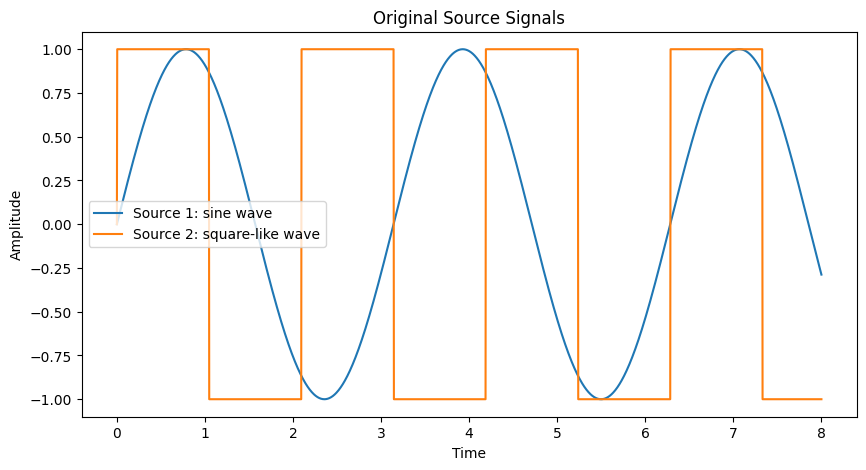

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(time, S[:, 0], label="Source 1: sine wave")
plt.plot(time, S[:, 1], label="Source 2: square-like wave")
plt.title("Original Source Signals")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

### Guided interpretation

From the plot above, you should notice that:
- the first source is smooth and periodic
- the second source switches sharply between values

These two signals are clearly different in shape, which makes them a good example for ICA.

---

### Step 4: Create a mixing matrix

Now we simulate what happens when the source signals are mixed together.

The mixing matrix tells us how much of each source contributes to each observed signal.

In [ ]:
A = np.array([[1.0, 1.0],
              [0.5, 2.0]])

print("Mixing matrix A:")
print(A)

Mixing matrix A:
[[1.  1. ]
 [0.5 2. ]]


### Step 5: Mix the source signals

We now compute the observed mixed signals using:

\[
X = SA^T
\]

This means we no longer observe the original sources directly.  
Instead, we observe combinations of them.

In [ ]:
X = S.dot(A.T)

print("Shape of mixed signal matrix X:", X.shape)

Shape of mixed signal matrix X: (2000, 2)


### Step 6: Visualize the mixed signals

Notice that the observed signals below no longer look like the original pure sine and square-like waves.

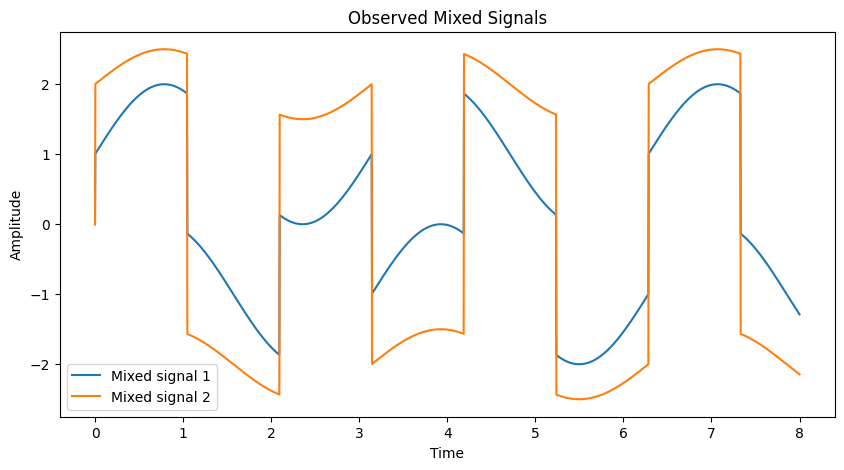

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(time, X[:, 0], label="Mixed signal 1")
plt.plot(time, X[:, 1], label="Mixed signal 2")
plt.title("Observed Mixed Signals")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

### Guided interpretation

At this point:
- the original signals are hidden inside the mixtures
- each observed signal contains information from both sources
- it is difficult to visually separate the original patterns just by looking at the mixed signals

This is the problem ICA is designed to solve.

---

### Step 7: Apply ICA

We now use `FastICA` from `sklearn.decomposition` to estimate the hidden independent sources.

In [ ]:
ica = FastICA(n_components=2, random_state=42)

S_est = ica.fit_transform(X)   # estimated sources
A_est = ica.mixing_            # estimated mixing matrix

print("Shape of recovered source matrix S_est:", S_est.shape)
print("Estimated mixing matrix:")
print(A_est)

Shape of recovered source matrix S_est: (2000, 2)
Estimated mixing matrix:
[[1.037525   0.71820221]
 [2.01612255 0.40295106]]


### Step 8: Visualize the recovered signals

These are the components recovered by ICA from the mixed observations.

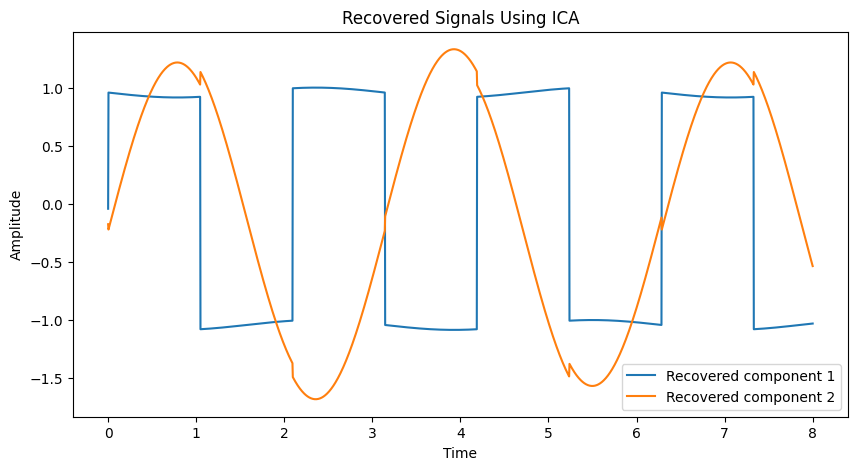

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(time, S_est[:, 0], label="Recovered component 1")
plt.plot(time, S_est[:, 1], label="Recovered component 2")
plt.title("Recovered Signals Using ICA")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

### Step 9: Compare original, mixed, and recovered signals together

This combined view helps us understand the full ICA workflow.

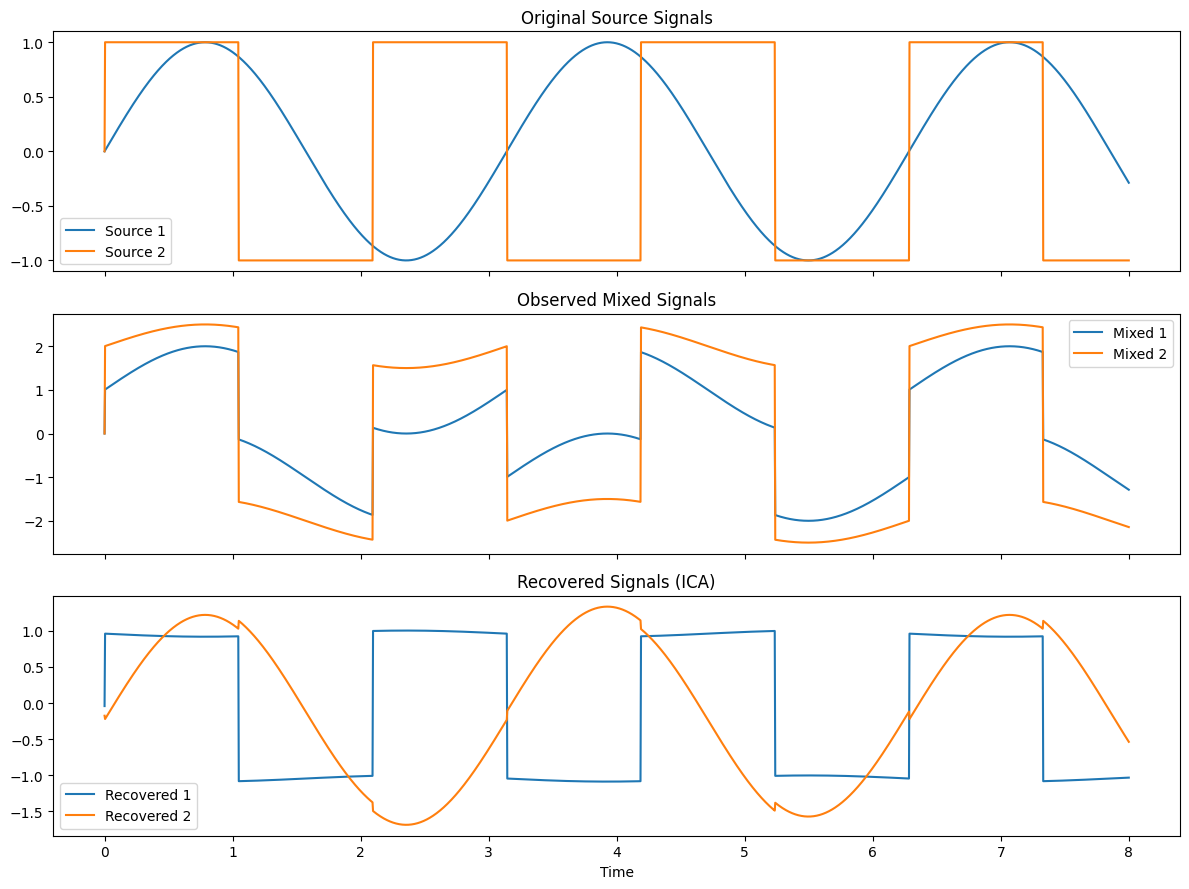

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(time, S[:, 0], label="Source 1")
axes[0].plot(time, S[:, 1], label="Source 2")
axes[0].set_title("Original Source Signals")
axes[0].legend()

axes[1].plot(time, X[:, 0], label="Mixed 1")
axes[1].plot(time, X[:, 1], label="Mixed 2")
axes[1].set_title("Observed Mixed Signals")
axes[1].legend()

axes[2].plot(time, S_est[:, 0], label="Recovered 1")
axes[2].plot(time, S_est[:, 1], label="Recovered 2")
axes[2].set_title("Recovered Signals (ICA)")
axes[2].legend()

plt.xlabel("Time")
plt.tight_layout()
plt.show()

## Guided Questions

### Q1. What happened to the original signals after mixing?

Write your answer here.

After mixing, the original signals lost their individual identity. The smooth sine wave and the sharp square wave were blended together, producing two new distorted signals. It became impossible to identify either original signal just by looking at them.

### Q2. When you compare the recovered signals with the original signals, what do you observe?

Write your answer here.

ICA successfully recovered the original patterns. One component clearly showed the periodic sine wave and the other showed the switching square wave. The shapes were not perfect, the signals appear flipped or scaled differently but, the fundamental patterns were clearly restored.

### Q3. Why do we say ICA is useful for source separation?

Write your answer here.

ICA is useful because it can recover original signals from mixtures without knowing how they were mixed. A real-world example is the cocktail party problem, multiple microphones pick up a blend of voices, and ICA isolates each individual voice from the mixture.

### Q4. Did ICA recover the signals in exactly the same order, sign, and scale?

Write your answer here.

No. ICA has three inherent limitations:

Order: the recovered signals may appear in any order

Sign: A recovered signal might appear upside down

Scale: the amplitude may differ from the original

These do not affect the usefulness of ICA because the underlying pattern and information are preserved.

## Short Concept Check: ICA vs PCA

ICA and PCA are both used to transform data, but they do different things.

### PCA
- finds directions of maximum variance
- produces components that are **uncorrelated**

### ICA
- tries to recover hidden source signals
- produces components that are as **independent** as possible

### Important difference
PCA is mainly about **variance and compression**, while ICA is mainly about **separating independent sources**.

---

### Q5. In your own words, how is ICA different from PCA?

Write your answer here.

PCA finds directions of maximum variance to compress data. It produces uncorrelated components. ICA goes further by finding statistically independent components to recover hidden source signals. The key difference is purpose: PCA is for dimensionality reduction, ICA is for source separation.


## Part B — Independent Practice

Now that you have seen one complete example, you will repeat the workflow with a modified setup.

You may do **one** or **both** of the following tasks.

---

## Task 1: Change the source signals

Create a new pair of source signals. For example, you may try:
- a cosine wave
- a sawtooth-like or sign-based signal
- a signal with added noise

Then:
1. stack them into a new source matrix
2. plot the original signals
3. choose a mixing matrix
4. mix the signals
5. apply ICA
6. plot the recovered signals
7. compare your results

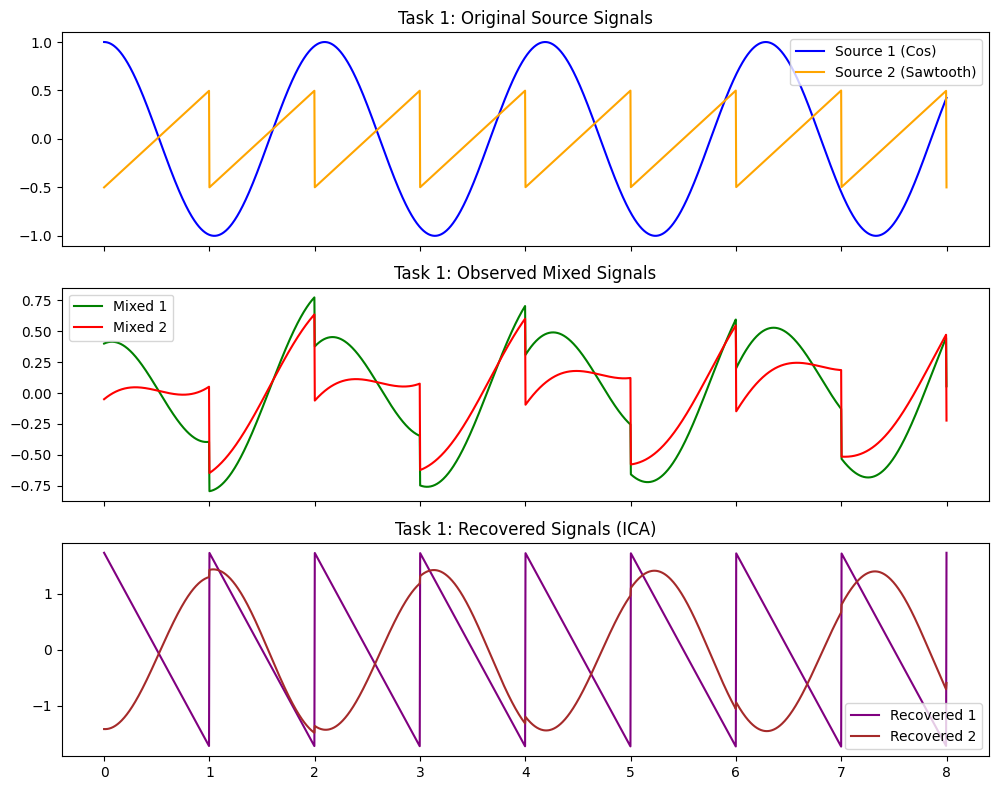

In [13]:
# YOUR CODE FOR TASK 1 STARTS HERE

# 1. Create a cosine wave and a sawtooth wave
s1_new = np.cos(3 * time)                                # Cosine wave
s2_new = (time % 1) - 0.5                                # Sawtooth wave
S_new = np.c_[s1_new, s2_new]

# 2. Choose a new mixing matrix
A_new = np.array([[0.6, 0.4],
                  [0.3, 0.7]])

# 3. Mix the signals
X_new = S_new.dot(A_new.T)

# 4. Apply ICA
ica_new = FastICA(n_components=2, random_state=42)
S_est_new = ica_new.fit_transform(X_new)

# 5. Plotting
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axes[0].plot(time, S_new[:, 0], label="Source 1 (Cos)", color='blue')
axes[0].plot(time, S_new[:, 1], label="Source 2 (Sawtooth)", color='orange')
axes[0].set_title("Task 1: Original Source Signals")
axes[0].legend()

axes[1].plot(time, X_new[:, 0], label="Mixed 1", color='green')
axes[1].plot(time, X_new[:, 1], label="Mixed 2", color='red')
axes[1].set_title("Task 1: Observed Mixed Signals")
axes[1].legend()

axes[2].plot(time, S_est_new[:, 0], label="Recovered 1", color='purple')
axes[2].plot(time, S_est_new[:, 1], label="Recovered 2", color='brown')
axes[2].set_title("Task 1: Recovered Signals (ICA)")
axes[2].legend()

plt.tight_layout()
plt.show()

## Task 2: Keep the source signals but change the mixing matrix

Use the same original source signals from Part A, but choose a different mixing matrix.

Then:
1. define a new mixing matrix
2. compute the new mixed signals
3. apply ICA
4. plot the results
5. compare them with the first guided example

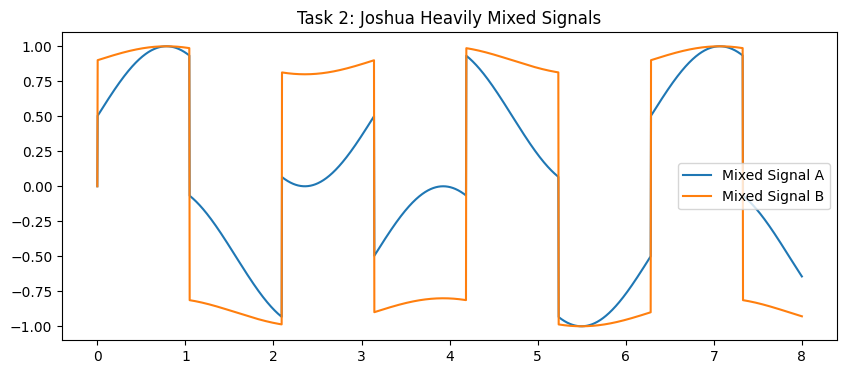

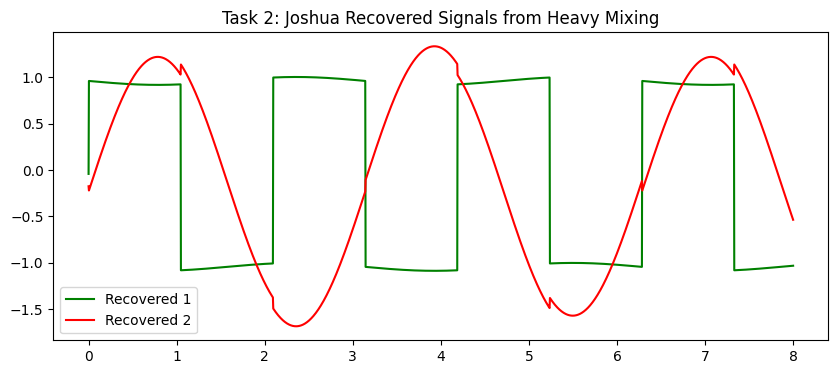

In [14]:
# YOUR CODE FOR TASK 2 STARTS HERE

# 1. Define a new, more complex mixing matrix
A_alt = np.array([[0.5, 0.5],
                  [0.1, 0.9]])

# 2. Compute the new mixed signals (using S from Part A)
X_alt = S.dot(A_alt.T)

# 3. Apply ICA
ica_alt = FastICA(n_components=2, random_state=42)
S_est_alt = ica_alt.fit_transform(X_alt)

# 4. Plotting
plt.figure(figsize=(10, 4))
plt.plot(time, X_alt[:, 0], label="Mixed Signal A")
plt.plot(time, X_alt[:, 1], label="Mixed Signal B")
plt.title("Task 2: Joshua Heavily Mixed Signals")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(time, S_est_alt[:, 0], label="Recovered 1", color='green')
plt.plot(time, S_est_alt[:, 1], label="Recovered 2", color='red')
plt.title("Task 2: Joshua Recovered Signals from Heavy Mixing")
plt.legend()
plt.show()

## Optional Challenge Task

Try adding a small amount of noise to the mixed signals before applying ICA.

Questions to think about:
- Does ICA still recover the signals well?
- Is the recovery less clear than before?
- What does this suggest about ICA in noisy real-world data?

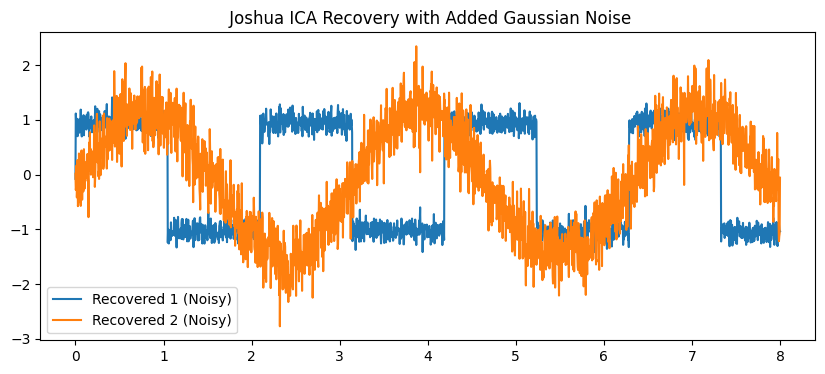

In [15]:
# # OPTIONAL CHALLENGE
noise = 0.1 * np.random.normal(size=X_alt.shape)
X_noisy = X_alt + noise

ica_noisy = FastICA(n_components=2, random_state=42)
S_est_noisy = ica_noisy.fit_transform(X_noisy)

# Visualize the effect of noise
plt.figure(figsize=(10, 4))
plt.plot(time, S_est_noisy[:, 0], label="Recovered 1 (Noisy)")
plt.plot(time, S_est_noisy[:, 1], label="Recovered 2 (Noisy)")
plt.title(" Joshua ICA Recovery with Added Gaussian Noise")
plt.legend()
plt.show()

## Final Discussion Questions

### Q6. In your independent task, was ICA able to recover the source patterns clearly?

Write your answer here.

Yes. Even with different waveforms such as a sawtooth and a cosine wave, ICA successfully isolated each signal. In the recovered plots, the sharp edges of the sawtooth and the smooth curves of the cosine were clearly visible and visually distinct, closely matching the original source patterns.

### Q7. What changes did you observe when you modified the source signals or the mixing matrix?

Write your answer here.

Changing the source signals showed that ICA is not limited to sine waves. As long as the sources are statistically independent and non-Gaussian, ICA can recover them regardless of their shape. Modifying the mixing matrix changed how the signals were blended, but ICA still managed to unmix them correctly, which confirmed that the algorithm does not need to know anything about the mixing process beforehand.


### Q8. If noise was added, how did it affect the recovered signals?

Write your answer here.

When noise was added, the recovered signals were no longer perfectly smooth, they contained rough edges and high-frequency disturbances. However, the overall shape of each signal remained clearly recognizable. This showed that ICA is reasonably robust to noise, but recovery quality decreases as the noise level increases and the signal to noise ratio drops.

### Q9. Based on this lab, when would ICA be more useful than PCA?

Write your answer here.

ICA is more useful when the goal is source separation rather than compression. From this lab I learned that PCA is the better choice when I want to reduce the size of my data or identify which features carry the most variance. ICA is the better choice when my data contains separate hidden signals that need to be individually recovered, such as isolating different voices in a room, separating brain wave signals in an EEG recording, or distinguishing individual instruments in a piece of music. The key lesson is that PCA simplifies data while ICA unmixes it.

## Final Reflection

In this lab, you learned that ICA can recover hidden source signals from mixtures when the sources are reasonably independent. You also saw that the quality of recovery can depend on the signals used, the mixing process, and the presence of noise.

The main takeaway is that ICA is especially useful when the goal is **source separation**, while PCA is more suitable when the goal is **dimensionality reduction and variance preservation**.